In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
# import src.statsmodels as statsmodels 
import copy
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [2]:
model = "word_task_v10_main_feature_gain_config_latest_ckpt"

analysis_dir = Path(f"/om/scratch/Thu/imgriff/binaural_unit_activations_for_anova/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
# for key in h5.keys():
    # print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()
valid_ixs = ~np.isnan(target_f0s)

target_f0s = target_f0s[valid_ixs]
target_locs = target_locs[valid_ixs]
target_words = h5["target_word_int"][valid_ixs]
target_talkers = h5["target_talker_id"][valid_ixs]
unique_word_int = np.unique(target_words)
unique_talker_int = np.unique(target_talkers)

<KeysViewHDF5 ['cochleagram_target', 'conv_block_0_relu_target', 'conv_block_1_relu_target', 'conv_block_2_relu_target', 'conv_block_3_relu_target', 'conv_block_4_relu_target', 'conv_block_5_relu_target', 'conv_block_6_relu_target', 'layer_names', 'relufc_target', 'target_f0', 'target_loc', 'target_talker_id', 'target_word_int', 'tested_azims']>


# Plot distribution of features in stimuli 

776
Optimal number of bins: 15
431


Text(0.5, 1.0, 'Talker distribution')

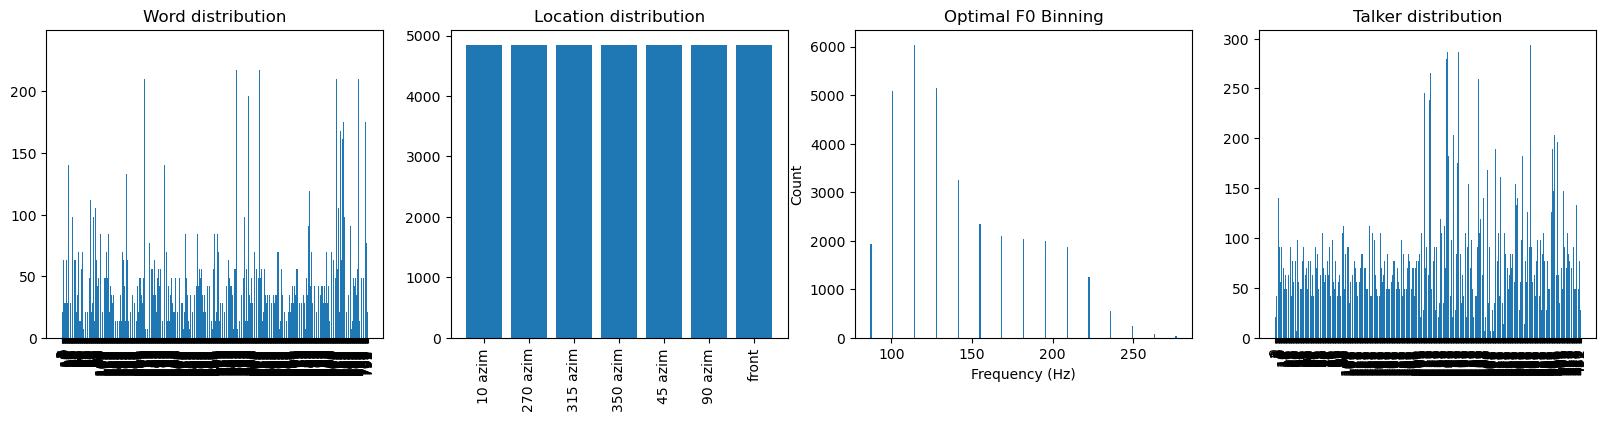

In [40]:
plt.figure(figsize=(20, 4))
plt.subplot(141)
words, count = np.unique(target_words, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(words))
plt.xticks(np.arange(len(count)), words.astype('int'), rotation=90);
plt.title('Word distribution')

### get binning for location classes 

#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
loc_list = np.zeros(len(target_locs), dtype=object)
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        loc_list[loc_ixs] = 'front'
    elif elev == 0:
        loc_list[loc_ixs] = f"{azim} azim"
    elif azim == 0:
        loc_list[loc_ixs] = f"{elev} elev"

plt.subplot(142)
locs, count = np.unique(loc_list, return_counts=True)
plt.bar(np.arange(len(count)), count)
plt.xticks(np.arange(len(locs)), locs, rotation=90);
plt.title('Location distribution')


### get binning for pitch classes 
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

plt.subplot(143)
# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = 15 #  optimal_bin_count(target_f0s)
bin_counts, bins = np.histogram(target_f0s, bins=optimal_bins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
f0_assignments = np.digitize(target_f0s, bins, right=True)

print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.bar(bin_centers, bin_counts)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal F0 Binning')


plt.subplot(144)
talkers, count = np.unique(target_talkers, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(talkers))
plt.xticks(np.arange(len(count)), talkers.astype('int'), rotation=90);
plt.title('Talker distribution')




array([ 3, 31, 33, ..., 11, 13,  5])

# Step-by-step demo of sinlge unit ANOVA

In [41]:
np.random.seed(0)

### Select single unit to fit 
layer_name = 'conv_block_0_relu_target'
unit_ix = 10 # just a random unit
unit_acts = h5[layer_name][valid_ixs, unit_ix]
n_examples = len(unit_acts)

# --- set up ANOVA table --- 
# create dataframe with activations as the dependent varialbe column, and feature categories as the factors
act_df = pd.DataFrame(unit_acts, columns=['activation'])
act_df['f0'] = [bins[assignment] for assignment in f0_assignments]
act_df['loc'] = loc_list
act_df['word'] = target_words
act_df['talker'] = target_talkers

# -- display first 5 fows -- 
print(act_df.head())

# -- define OLS model formula --
formula = "activation ~ C(f0) + C(loc) + C(word) + C(talker)"

# -- fit the model --
model = ols(formula, act_df).fit()

# -- fit ANOVA --
anova_table = sm.stats.anova_lm(model, typ=1)

   activation        f0    loc   word  talker
0    0.092957   94.0625  front  714.0   243.0
1    0.116638  202.1250  front  715.0    27.0
2    0.099426  202.1250  front  749.0   368.0
3    0.084106  121.1250  front  453.0   373.0
4    0.074158  134.6250  front  449.0   391.0


In [42]:
anova_table = sm.stats.anova_lm(model, typ=1)
total_ss = anova_table.sum_sq.sum()
ssq = anova_table['sum_sq'][:-1]
prop_var = ssq / total_ss
prop_var

C(f0)        0.038599
C(loc)       0.045553
C(word)      0.212470
C(talker)    0.501295
Name: sum_sq, dtype: float64

In [43]:
anova_table = sm.stats.anova_lm(model, typ=2)
total_ss = anova_table.sum_sq.sum()
ssq = anova_table['sum_sq'][:-1]
prop_var = ssq / total_ss
prop_var

C(f0)        0.000884
C(loc)       0.055019
C(word)      0.094551
C(talker)    0.605469
Name: sum_sq, dtype: float64